In [32]:
import sys
from pathlib import Path 
from src.data.extracting import readData

projectRoot = Path.cwd().parent.parent
sys.path.append(str(projectRoot))

import src.models.kmeans as clusterModel
from src.data.extracting import readData
import src.data.charts as Painter

processedData = readData("processed")

scores = clusterModel.evaluateCluster(processedData)
df_to_work = readData('clean')

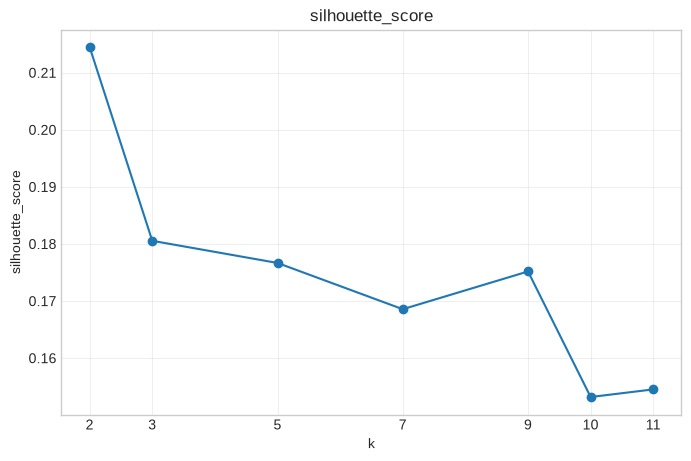

In [33]:
Painter.drawPLot(scores, "k", "silhouette_score")

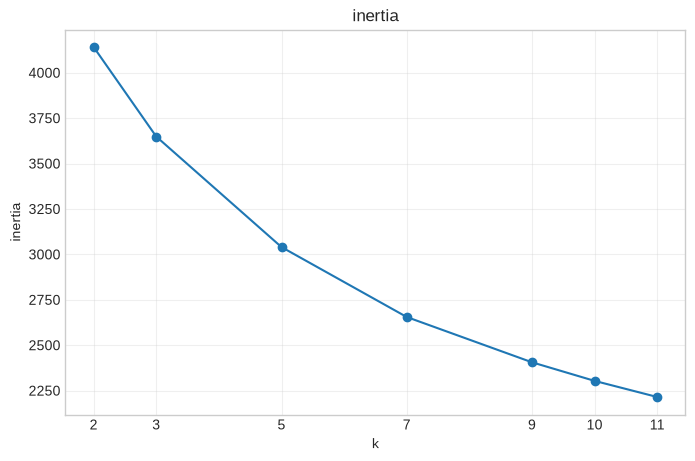

In [34]:
Painter.drawPLot(scores, 'k', 'inertia')

In [ ]:
labels = clusterModel.implemetnKmeans(processedData, 2)
print(labels)
clustered_df = clusterModel.clusterResult(processedData, labels)

groupedCLuster = clustered_df.groupby('cluster').size()

display(groupedCLuster)



[1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 0 0 1
 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 0 0 1 1
 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1
 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0
 1 0 1 0 1 1 1 1 0 0 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0
 1 1 1 0 1 0 1 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1
 0 1 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1
 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1
 1 1 1 1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 0 1
 0 0 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1
 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0
 0 1 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 1 1 0 1 1 0 0 0
 0 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1
 1 0 0 1 1 1 1 0 1 0 1 0 

cluster
0    408
1    360
dtype: int64

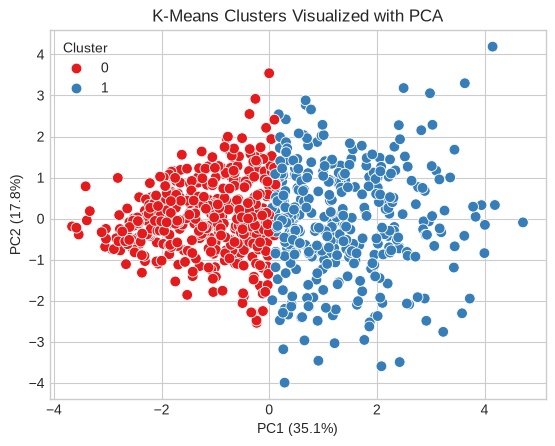

In [39]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plotClustersPCA(processedData, labels):

    pca = PCA(n_components=2)

    components = pca.fit_transform(processedData)

    pca_df = pd.DataFrame(
        components,
        columns=["PC1", "PC2"]
    )

    pca_df["cluster"] = labels

    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="Set1",
        s=60
    )

    plt.title("K-Means Clusters Visualized with PCA")
    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
    )
    plt.legend(title="Cluster")
    plt.show()
plotClustersPCA(processedData , labels)

In [36]:
clustered_df.groupby("cluster").mean(numeric_only=True)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
cluster,,,,,,,
0,105.843137,67.377451,23.932190,104.460784,28.894363,0.417615,28.335784
1,139.422222,78.127778,34.656481,202.594444,36.444444,0.527246,38.800000
